## Research Question 2
The second part of the original question has been reworded for clarity, and will be the focus of the first part of the investigation:

1. Can delays in seller handoff to the logistics carrier help us anticipate customer-facing delivery issues?
2. Which sellers consistently delay order handoffs to carriers, and what underlying patterns or behaviors contribute to this?  

### Part 0: Reduce data set to only the features relevant to this analysis

We first import the 'clean' dataset all team members have agreed to use as the starting point for analysis:

In [90]:
import os
import pandas as pd

os.chdir(r'C:\Users\opiwa\Documents\ASU\DAT_490\Data') # using raw literal to allow copy/paste from Windows paths
data = pd.read_csv('cleaned_dataset.csv', index_col = False, low_memory = False);

We will drop the following irrelevant columns since we have already generated an approximate distance between seller and customer in the 'distance_km' field:
 - customer_lat & customer_lng - the latitude and longitude coordinates of the customer
 - seller_lat & seller_lng - the latitude and longitude coordinates of the seller

We also drop 'is_first_time_buyer' as that has no logical reason to affect shippers' effectiveness at handing off deliveries.  Finally, we drop the "informational" product fields (length of name, length of description, number of photos) as well as the remaining review information, as neither of those groups are relevant to the question at hand.

In [93]:
data.drop(columns = ['customer_lat', 'customer_lng', 'is_first_time_buyer', 
                     'seller_lat', 'seller_lng', 'product_name_length', 'product_description_length', 
                     'product_photos_qty', 'review_id', 'review_score'], inplace=True);

In [95]:
data.columns

Index(['order_id', 'order_item_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_estimated_delivery_date', 'is_canceled',
       'customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'order_delivered_customer_date',
       'seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'shipping_limit_date', 'order_delivered_carrier_date', 'handoff_delay',
       'distance_km', 'product_id', 'product_category_name_english', 'price',
       'freight_value', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'delivered_late',
       'delivery_delay'],
      dtype='object')

There are features left of questionable relevance, but we will keep them just in case they become important as the analysis proceeds.

To reduce the complexity of the set, we next extract the unique values within the order_id, customer_id, customer_unique_id, and seller_id columns so we can assign integer values to them in place of the 32-character hexadecimal values that are currently in place, since we have no need to trace those values back to the original databases.  We then join the resulting individual dataframes with the larger data set, dropping the original columns and leaving only the integer IDs.

In [98]:
# Create dataframes from extracted unique values of each ID column in the overall 'data' dataset
order = pd.DataFrame(data['order_id'].unique(), columns = ['order_id'])
cust = pd.DataFrame(data['customer_id'].unique(), columns = ['customer_id'])
cust_u = pd.DataFrame(data['customer_unique_id'].unique(), columns = ['customer_unique_id'])
sell = pd.DataFrame(data['seller_id'].unique(), columns = ['seller_id'])

# Add the integer index values to each set
order['order_id_int'] = range(1, len(order['order_id'])+1)
cust['customer_id_int'] = range(1, len(cust['customer_id'])+1)
cust_u['customer_unique_id_int'] = range(1, len(cust_u['customer_unique_id'])+1)
sell['seller_id_int'] = range(1, len(sell['seller_id'])+1)

# Merge each ID dataframe 'dictionary' to the greater dataset, then drop the original column, renaming the new column to the old name for consistency
data = data.merge(order, how = 'left', on = 'order_id')
data.drop(columns = 'order_id', inplace = True)
data = data.merge(cust, how = 'left', on = 'customer_id')
data.drop(columns = 'customer_id', inplace = True)
data = data.merge(cust_u, how = 'left', on = 'customer_unique_id')
data.drop(columns = 'customer_unique_id', inplace = True)
data = data.merge(sell, how = 'left', on = 'seller_id')
data.drop(columns = 'seller_id', inplace = True);

# Rename *_int columns to the original names
data.rename(columns = {'order_id_int':'order_id', 'customer_id_int':'customer_id', 'customer_unique_id_int':'customer_unique_id', 'seller_id_int':'seller_id'}, inplace=True)

# We also realize there were order in process when this set was published, so we will remove rows where there is no delivery date to the customer
data = data.dropna(subset = 'order_delivered_customer_date')

data.shape

(109306, 31)

### Part 1: Seller Handoff Delays and Correlation with Customer Delivery Delays

To recapitulate from the EDA (see the column name list after the original data loading and first drop operation above), features already exist that show the following:
1. 'delivered_late' - True/False indicator of if the 'order_delivered_customer_date' was later than the 'order_estimated_delivery_date'
2. 'delivery_delay' - Difference between 'order_delivered_customer_date' and 'order_estimated_delivery_date' in days, negative values being early deliveries and positive values being late deliveries.
3. 'handoff_delay' - Difference between 'order_delivered_carrier_date' and 'order_approved_at' in days

Since it's not clear if Olist has a policy that only allows sellers to be informed of a purchase needing shipment after payment has been approved or not, we will create a new field ('handoff_delay_alt') based on the difference between 'order_deliveredd_carrier_date' and 'order_purchase_timestamp' to see if that has less instances of negative values for the "delay", since it should be physically impossible to deliver the product for shipment without even knowing of the existence of an order.  The only negative values should be -1, and only then if the vagaries of time stamping across the four time zones spanning Brazil have an effect on the delivery/origin datetimes instead of the system adopting a universal time frame and enforcing it across the database.  We convert the various date/time fields to Pandas datetime datatype since the original import interpreted them as strings.

In [101]:
print(data.dtypes)

order_item_id                    float64
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_estimated_delivery_date     object
is_canceled                         bool
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_delivered_customer_date     object
seller_zip_code_prefix           float64
seller_city                       object
seller_state                      object
shipping_limit_date               object
order_delivered_carrier_date      object
handoff_delay                    float64
distance_km                      float64
product_id                        object
product_category_name_english     object
price                            float64
freight_value                    float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm

In [103]:
# Convert date fields to the datetime datatype
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp']);
data['order_approved_at'] = pd.to_datetime(data['order_approved_at']);
data['order_estimated_delivery_date'] = pd.to_datetime(data['order_estimated_delivery_date']);
data['shipping_limit_date'] = pd.to_datetime(data['shipping_limit_date']);
data['order_delivered_carrier_date'] = pd.to_datetime(data['order_delivered_carrier_date']);
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date']);

data['handoff_delay_alt'] = (data['order_delivered_carrier_date'] - data['order_purchase_timestamp']).dt.days

# See descriptive statistics
print(data['handoff_delay_alt'].describe())

count    109305.000000
mean          3.255496
std           3.600074
min        -171.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         104.000000
Name: handoff_delay_alt, dtype: float64


Instead of plotting a histogram and comparing to EDA historgram, it's easier to compare number of negative delivery delay values in each column:

In [106]:
neg = len(data[data['handoff_delay']<-1])
neg_alt = len(data[data['handoff_delay_alt']<-1])
print(f"There are {neg} handoff delay values less than -1 in the original delay field and {neg_alt} in the alternative field");

There are 83052 handoff delay values less than -1 in the original delay field and 2 in the alternative field


Clearly, our original definition of handoff delay did not line up with the Oline business rules surrounding date/time recording in their database.  We will use the 'alt' value for all future comparisons.  If either of the values are -1, we will convert them to 0 and chalk it up to the time zone differences mentioned previously, otherwise we will drop those rows as errors we cannot resolve.

In [109]:
print(data['handoff_delay_alt'].nsmallest(2))

29025   -171.0
93479     -4.0
Name: handoff_delay_alt, dtype: float64


In [111]:
# Drop two negative rows since they both have absolute values greater than 1
data.drop(index = [29025,93479], inplace=True);

# Drop the original handoff_delay column as it is no longer necessary, rename the alternative to replace it
data.drop(columns = 'handoff_delay', inplace=True);
data.rename(columns = {'handoff_delay_alt':'handoff_delay'}, inplace=True);

In [113]:
data.shape

(109304, 31)

We now create a field ('promised_handoff_delay') that measures the difference between the 'order_delivered_carrier_date' field and the 'shipping_limit_date' field to determine if a handoff was early or late, much like the 'delivery_delay' field discussed above.

In [116]:
data['promised_handoff_delay'] = (data['order_delivered_carrier_date'] - data['shipping_limit_date']).dt.days

We are finally in position to determine the answer to the first part of the research question.  First, we determine if there is a correlation between the overall handoff delivery delay ('handoff_delay') and the amount of time early/late the handoff is made to the carrier ('promised_handoff_delay') to help determine the effectiveness of the system's handoff delivery time estimate mechanism.  We will use the Spearman correlation method, since it has better performance when dealing with discrete, non-normal data.  We will not use Kendall's correlation (tau) method, since it concerns rank correlations between sets, and we do not have ranked individual values, but rather pairwise discrete values.

In [137]:
from scipy.stats import spearmanr

corr, p = spearmanr(data['handoff_delay'], data['promised_handoff_delay'], axis = 0, nan_policy='omit');
print(f"The Spearman correlation coefficient for time to handoff and days early/late for handoff compared to the promise date \nis {corr:.3f} with an associated p-value for the comparison of {p}.")

The Spearman correlation coefficient for time to handoff and days early/late for handoff compared to the promise date 
is 0.529 with an associated p-value for the comparison of 0.0.


Since the p-value is 0.0, we reject the null hypothesis that the two sets do not have an ordinal correlation.  Based on the correlation coefficient, promised handoff delay should increase as the time it takes to make the handoff increases.  We can confirm that general relationship with a scatter plot.

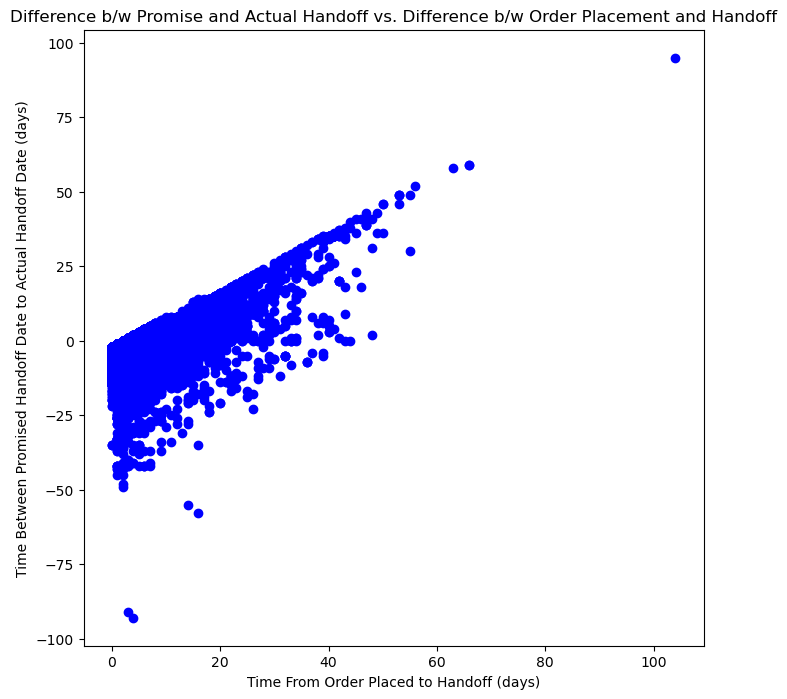

In [146]:
import matplotlib.pyplot as plt

# Limit single extreme outlier by only plotting times 5 months early or less

plt.figure(figsize = (8,8))
plt.scatter(x = data[data['promised_handoff_delay']>-150]['handoff_delay'], y = data[data['promised_handoff_delay']>-150]['promised_handoff_delay'], color = 'blue', marker = 'o')
plt.xlabel('Time From Order Placed to Handoff (days)')
plt.ylabel('Time Between Promised Handoff Date to Actual Handoff Date (days)')
plt.title('Difference b/w Promise and Actual Handoff vs. Difference b/w Order Placement and Handoff')
plt.show()

We can clearly see that there is a general trend where the longer the time it takes to hand the order off from its origination date, the more likely the handoff is to be late, and the more likely the "magnitude of the lateness", so to speak, will be larger than for shorter handoff times.

With that knowledge in hand, we can now see if there's a similar relationship between how late a handoff is made, and how late a delivery is made to the customer (if any), which is the first half of the answer we need to the greater question in this part of the analysis.

In [151]:
corr2, p2 = spearmanr(data['promised_handoff_delay'], data['delivery_delay'], axis = 0, nan_policy='omit');

print(f"The Spearman correlation coefficient for days early/late for handoff compared to days early/late \nfor delivery to the customer is {corr2:.3f} with an associated p-value for the comparison of {p2:.3f}.")

The Spearman correlation coefficient for days early/late for handoff compared to days early/late 
for delivery to the customer is 0.297 with an associated p-value for the comparison of 0.000.


While this correlation is still statistically significant, it is a much weaker relationship than for the previous correlation.  We will now plot this relationship in the same fashion as above to hopefully illustrate why the relationship is weaker.

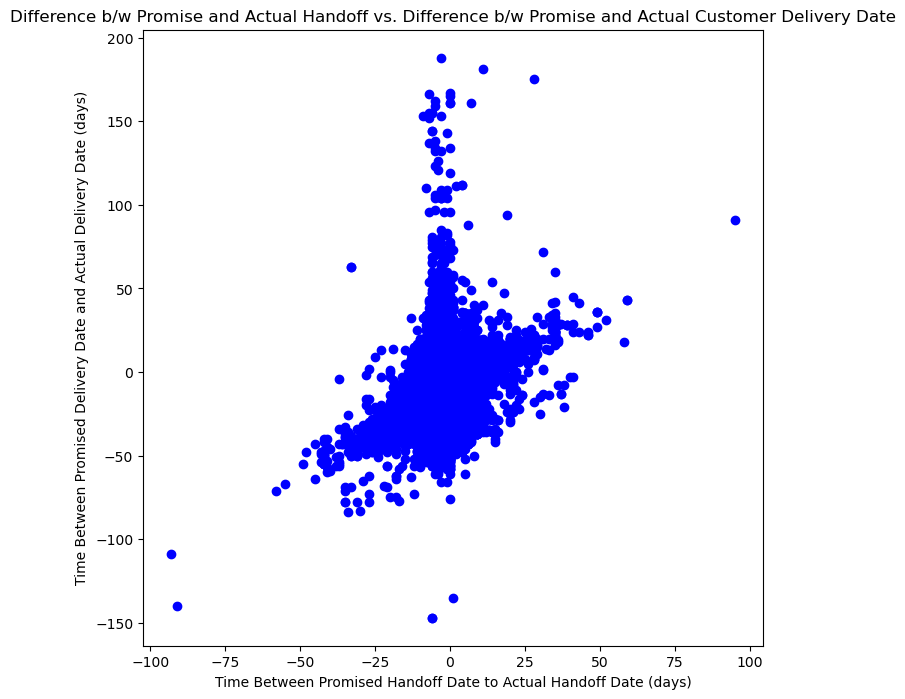

In [156]:
plt.figure(figsize = (8,8))
plt.scatter(x = data[data['promised_handoff_delay']>-150]['promised_handoff_delay'], y = data[data['promised_handoff_delay']>-150]['delivery_delay'], color = 'blue', marker = 'o')
plt.ylabel('Time Between Promised Delivery Date and Actual Delivery Date (days)')
plt.xlabel('Time Between Promised Handoff Date to Actual Handoff Date (days)')
plt.title('Difference b/w Promise and Actual Handoff vs. Difference b/w Promise and Actual Customer Delivery Date')
plt.show()

We definitely have multiple factors influencing the results in this case, which is why the correlation is weaker than for just the handoff comparison alone.  This makes sense given that we're not only considering the results of the process by which various sellers get their products to the carriers, but also the processes by which those carriers get the products to customers all over Brazil. We saw in the EDA that there is considerable variance in delivery delay across regions, which is only one factor influencing the results displayed above.